In [3]:
import pandas as pd

# Cargar el dataset
df = pd.read_csv("../data/youtoxic_english_1000.csv")

# Dimensiones: filas y columnas
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

# Primeras filas para ver la pinta general
df.head()

Filas: 1000, Columnas: 15


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
# Eliminar duplicados exactos por texto
df = df.drop_duplicates(subset='Text', keep='first').reset_index(drop=True)
print("Filas después de eliminar duplicados:", df.shape[0])

Filas después de eliminar duplicados: 997


IsHatespeech
False    859
True     138
Name: count, dtype: int64
IsHatespeech
False    86.158475
True     13.841525
Name: proportion, dtype: float64


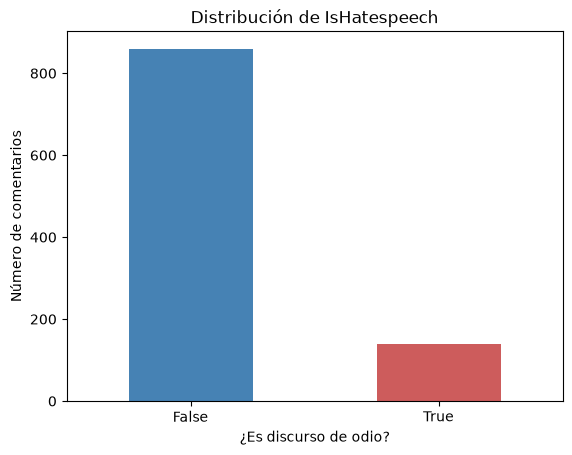

In [5]:
import matplotlib.pyplot as plt

print(df['IsHatespeech'].value_counts())
print(df['IsHatespeech'].value_counts(normalize=True) * 100)

df['IsHatespeech'].value_counts().plot(kind='bar', color=['steelblue', 'indianred'])
plt.title('Distribución de IsHatespeech')
plt.xlabel('¿Es discurso de odio?')
plt.ylabel('Número de comentarios')
plt.xticks(rotation=0)
plt.show()

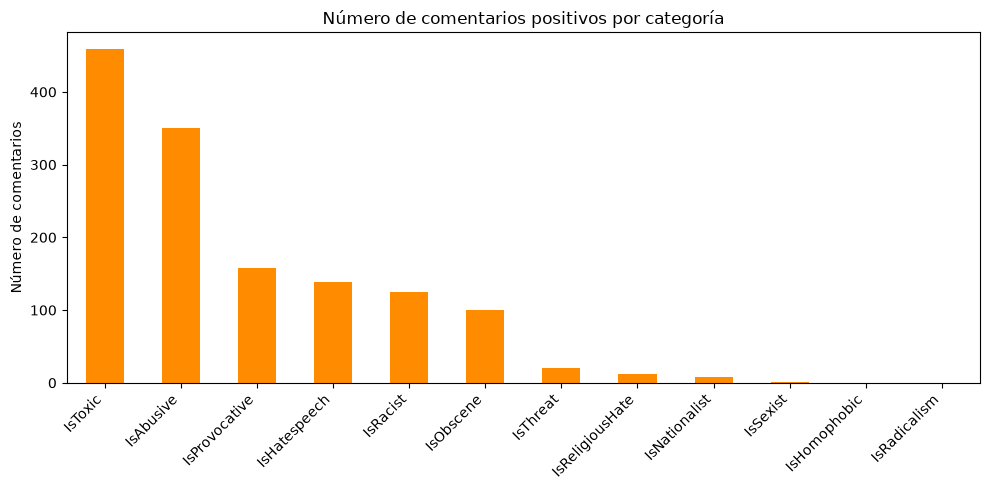

In [6]:
columnas_etiquetas = ['IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene',
                       'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist',
                       'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']

conteos = df[columnas_etiquetas].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
conteos.plot(kind='bar', color='darkorange')
plt.title('Número de comentarios positivos por categoría')
plt.ylabel('Número de comentarios')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

       longitud_caracteres  longitud_palabras
count           997.000000         997.000000
mean            186.073220          33.868606
std             271.022372          49.114220
min               3.000000           1.000000
25%              47.000000           9.000000
50%             102.000000          19.000000
75%             217.000000          39.000000
max            4421.000000         815.000000


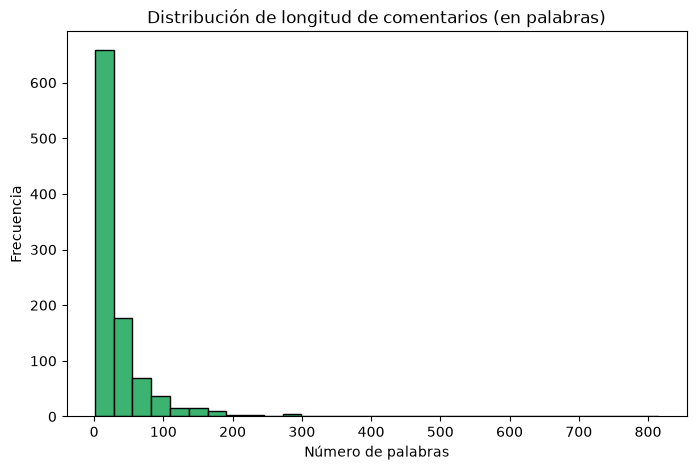

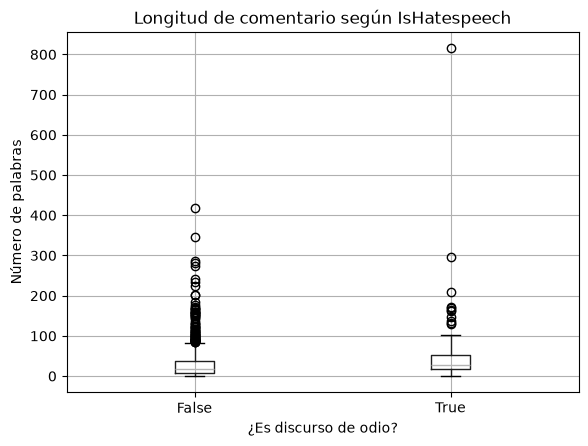

In [7]:
df['longitud_caracteres'] = df['Text'].str.len()
df['longitud_palabras'] = df['Text'].str.split().str.len()

print(df[['longitud_caracteres', 'longitud_palabras']].describe())

plt.figure(figsize=(8, 5))
plt.hist(df['longitud_palabras'], bins=30, color='mediumseagreen', edgecolor='black')
plt.title('Distribución de longitud de comentarios (en palabras)')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.show()

df.boxplot(column='longitud_palabras', by='IsHatespeech')
plt.title('Longitud de comentario según IsHatespeech')
plt.suptitle('')
plt.xlabel('¿Es discurso de odio?')
plt.ylabel('Número de palabras')
plt.show()

In [8]:
from collections import Counter

palabras_odio = ' '.join(df[df['IsHatespeech'] == True]['Text']).lower().split()
palabras_no_odio = ' '.join(df[df['IsHatespeech'] == False]['Text']).lower().split()

print("Top 15 palabras en comentarios de ODIO:")
print(Counter(palabras_odio).most_common(15))

print("\nTop 15 palabras en comentarios SIN odio:")
print(Counter(palabras_no_odio).most_common(15))

Top 15 palabras en comentarios de ODIO:
[('the', 268), ('and', 159), ('a', 150), ('to', 139), ('of', 119), ('is', 88), ('in', 86), ('black', 76), ('this', 75), ('people', 59), ('they', 58), ('you', 57), ('that', 55), ('it', 54), ('was', 54)]

Top 15 palabras en comentarios SIN odio:
[('the', 1273), ('to', 670), ('and', 648), ('a', 634), ('of', 480), ('is', 442), ('that', 388), ('you', 367), ('i', 348), ('in', 345), ('this', 289), ('are', 263), ('for', 207), ('was', 205), ('they', 197)]


## Conclusiones del EDA

- Dataset: 997 filas tras eliminar 3 duplicados exactos por texto (de 1000 originales).
- Sin valores nulos ni comentarios vacíos.
- Variable objetivo `IsHatespeech`: 13.8% positivos (138/997) → dataset desbalanceado.
  Se gestionará con class_weight/SMOTE y métricas de precision/recall/F1 en la clase
  minoritaria (no solo accuracy).
- Longitud de comentarios muy sesgada a la derecha (mediana 19 palabras, máximo 815).
  El outlier de 815 palabras es un caso real de discurso de odio, no ruido.
- Los duplicados detectados diferían solo en mayúsculas/minúsculas → confirma la
  necesidad de normalizar el texto a minúsculas antes de vectorizar.
- Las palabras más frecuentes en ambas clases son mayoritariamente stopwords, salvo
  en la clase de odio, donde aparecen términos de contenido ("black", "people") →
  confirma la necesidad de eliminar stopwords para no diluir la señal real.